# EXPLORATORY DATA ANALYSIS

**Author:** Gordon Moenga

## Introduction

This analysis explores FinTrust's customer and transaction data to identify patterns in customer behaviour, transaction activity, transaction values, channels, transaction performance and risk review patterns. Python, Pandas, NumPy, Matplotlib and Seaborn were used to analyse the data and create visualizations. The findings provide additional insight into the data and support FinTrust's business and decision making needs.

Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Load the Datasets

In [2]:
transactions = pd.read_csv('transactions')
customers = pd.read_csv('customers')

In [3]:
print("transactions shape:", transactions.shape)
print("customers shape:", customers.shape)

transactions shape: (12000, 11)
customers shape: (1500, 12)


In [21]:
transactions["Transaction_DateTime"] = pd.to_datetime(transactions["Transaction_DateTime"])

## 1. Customer behaviour: Digital engagement by segment

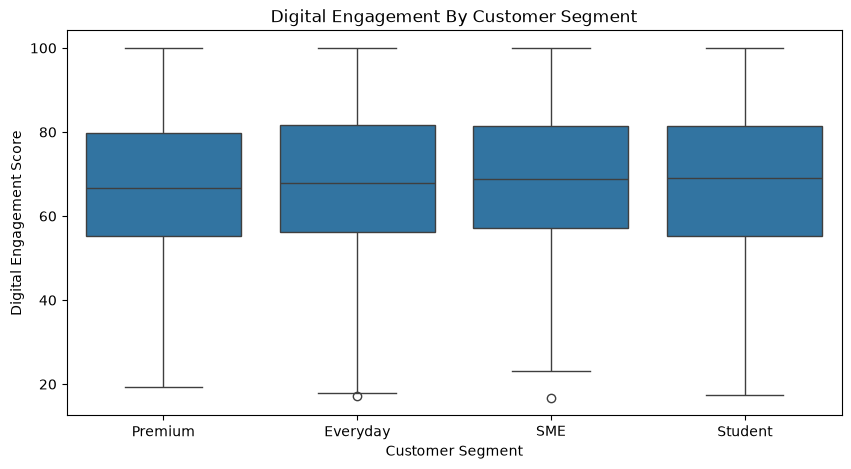

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x=customers['Customer_Segment'],
    y=customers['Digital_Engagement_Score']
)

plt.title("Digital Engagement By Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Digital Engagement Score")
plt.show()

**What does it show?**
The boxplot shows the distribution of digital engagement scores across the four customer segments. The median engagement score is fairly similar across all segments, with most scores falling roughly between the mid 50s and low 80s.

**Why is it important?**
It helps FinTrust compare digital engagement across customer groups and identify whether any segment has noticeably different engagement levels or unusual values.

**Business insight:**
Digital engagement is broadly similar across the four customer segments, with no major difference in the median scores. There are a few unusually low engagement scores in the Everyday and SME segments, which could be investigated further to understand the behaviour of those customers.

## 2. Transaction Amounts

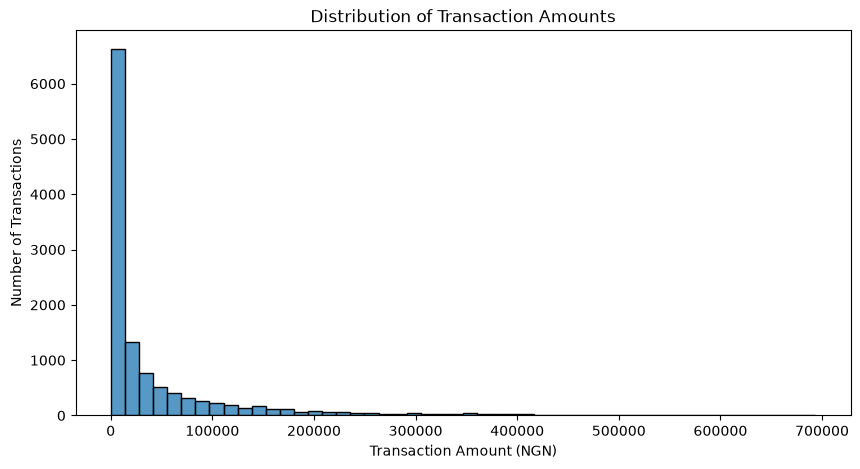

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(transactions['Amount_NGN'], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (NGN)")
plt.ylabel("Number of Transactions")
plt.show()

**What does it show?**
The distribution of transaction amounts and how transaction values are concentrated across the dataset.

**Why is it important?**
It helps distinguish typical transaction values from unusually high value transactions.

**Business insight:**
Transaction values are concentrated toward the lower end, with a smaller number of much higher value transactions. This supports the earlier finding that the transaction amount distribution contains potential high value outliers.

## 3. Transaction value by channel

In [16]:
# create channel value table
channel_value = (
    transactions.groupby('Channel')['Amount_NGN']
    .sum()
    .sort_values(ascending=False)
)

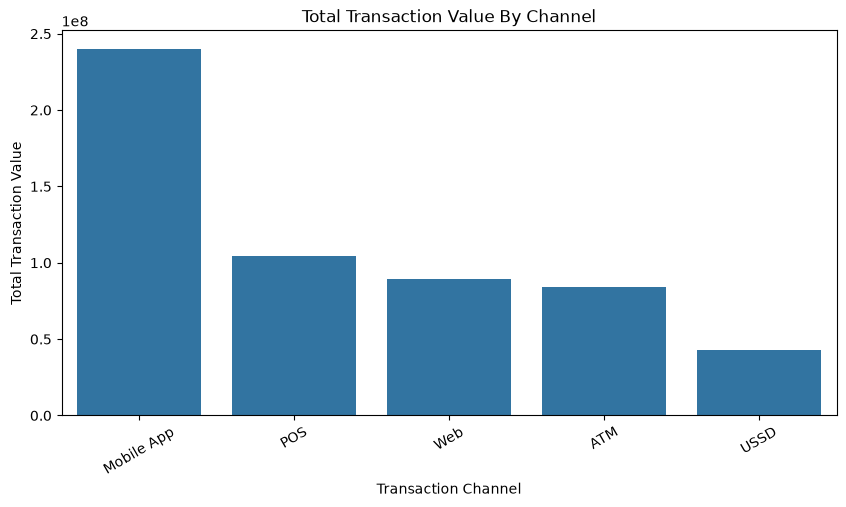

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=channel_value.index,
    y=channel_value.values
)

plt.title("Total Transaction Value By Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=30)
plt.show()

**What does it show?**
The total value of transactions processed through each channel.

**Why is it important?**
Transaction volume alone does not tell us how much financial activity each channel handles.

**Business insight:**
The Mobile App handles the largest total transaction value, showing that it is important not only because of its transaction volume but also because of the value processed through the channel.

## 4. Monthly Transaction Trend

In [34]:
# create a monthly transactions table
monthly_transactions = (
    transactions
    .set_index("Transaction_DateTime")
    .resample("ME")
    .agg(
        Transaction_count=("Transaction_ID", "count"),
        Transaction_Value=("Amount_NGN", "sum")
    )
    .reset_index()
)
monthly_transactions

,Transaction_DateTime,Transaction_count,Transaction_Value
0,2026-01-31,4133,1.884894e+08
1,2026-02-28,3734,1.757869e+08
2,2026-03-31,4133,1.962010e+08


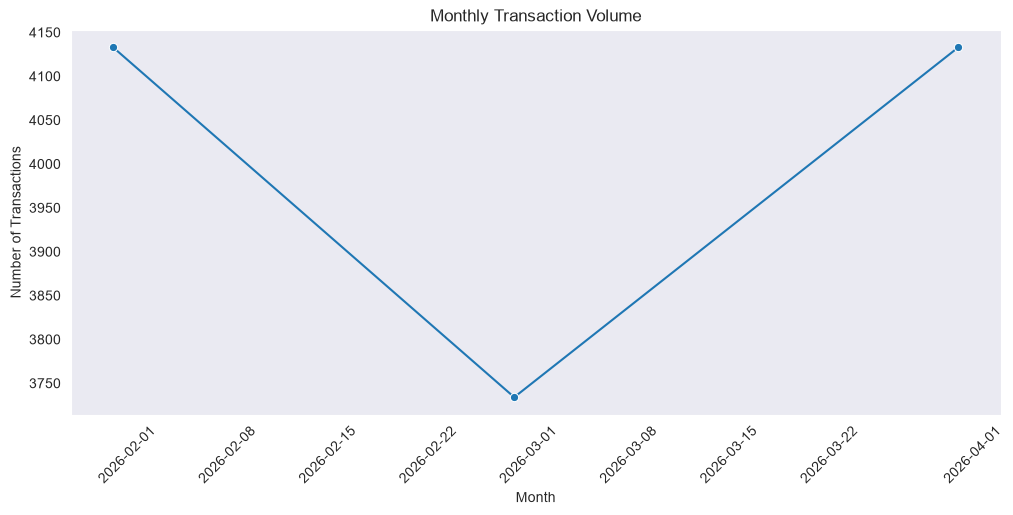

In [39]:
sns.set_style("dark")
plt.figure(figsize=(12,5))
sns.lineplot(
    x=monthly_transactions['Transaction_DateTime'],
    y=monthly_transactions['Transaction_count'],
    marker='o'
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

**What does it show?**
The analysis shows that transaction volume was highest in January and March, with 4,133 transactions in each month. February had the lowest volume at 3,734 transactions. Transaction value followed a similar pattern, with March recording the highest value at approximately NGN 196.20 million, followed by January at NGN 188.49 million and February at NGN 175.79 million.

**Why is it important?**
It helps FinTrust understand how transaction activity and value change over time. This can support monitoring of transaction demand and identification of periods with higher or lower activity.

**Business insight:**
March recorded the highest transaction value and returned to the same transaction volume as January after the February decline. This suggests that transaction activity was lower in February but increased again in March. FinTrust could monitor future months to determine whether this pattern continues.

## 5. Transaction success rate by channel

In [41]:
# check whether performance differs between channels
channel_status = pd.crosstab(
    transactions['Channel'],
    transactions['Transaction_Status'],
    normalize='index'
) * 100

channel_status

Transaction_Status,Failed,Pending,Reversed,Successful
Channel,,,,
ATM,4.178592,1.431025,2.690326,91.700057
Mobile App,5.801646,1.607213,2.842023,89.749118
POS,5.223569,1.420811,2.507313,90.848308
USSD,5.399325,1.012373,3.262092,90.326209
Web,4.708400,2.033173,2.407705,90.850722


In [44]:
success_rate = (
    transactions.assign(
        Successful=transactions['Transaction_Status'].eq('Successful')
    )
    .groupby('Channel')['Successful']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
success_rate

Channel
ATM           91.700057
Web           90.850722
POS           90.848308
USSD          90.326209
Mobile App    89.749118
Name: Successful, dtype: float64

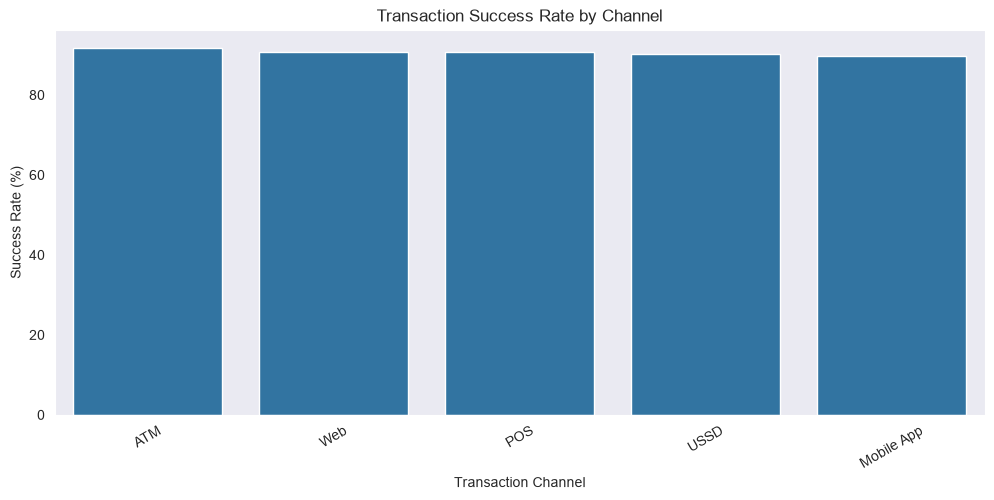

In [43]:
plt.figure(figsize=(12,5))
sns.barplot(
    x=success_rate.index,
    y=success_rate.values
)

plt.title("Transaction Success Rate by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=30)

plt.show()

**What does it show?**
The success rate was highest for ATM transactions at 91.70%, followed by Web at 90.85%, POS at 90.85%, USSD at 90.33%, and Mobile App at 89.75%.

**Why is it important?**
The overall transaction success rate can hide differences between individual channels. Comparing channels helps identify where transaction processing may be performing differently.

**Business insight:**
All channels have success rates above 89%, indicating relatively similar transaction performance across channels. Mobile App has the lowest success rate at 89.75%, so its unsuccessful transactions could be examined further to identify possible causes.

# 6. Risk review rate by transaction type

In [45]:
risk_by_type = (
    transactions.groupby('Transaction_Type')['Risk_Review_Flag']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)
risk_by_type

Transaction_Type
Transfer           28.486898
Cash Withdrawal    25.314685
Deposit            16.189759
Airtime/Data       15.189873
Card Purchase      13.023409
Bill Payment       12.813559
Name: Risk_Review_Flag, dtype: float64

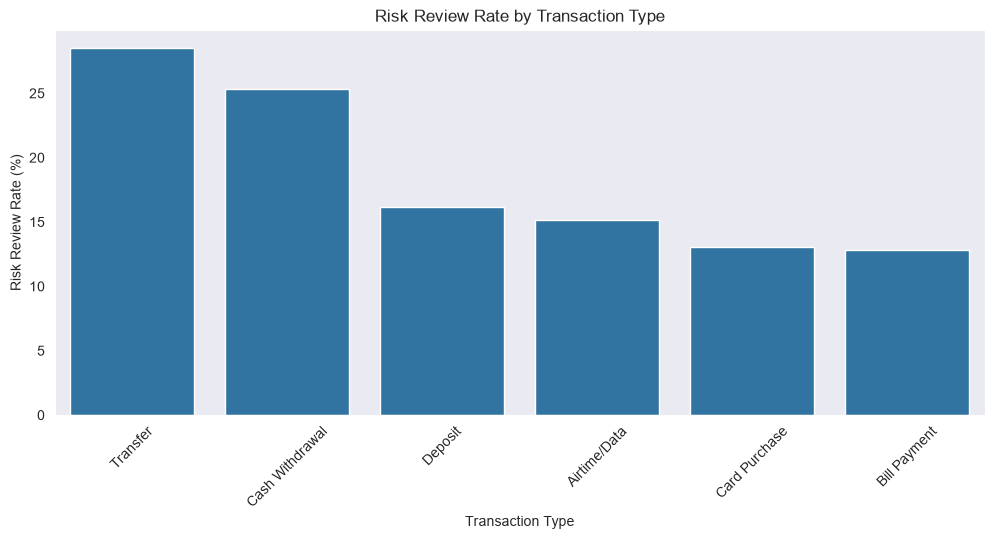

In [47]:
plt.figure(figsize=(12,5))
sns.barplot(
    x=risk_by_type.index,
    y=risk_by_type.values
)

plt.title("Risk Review Rate by Transaction Type")
plt.ylabel("Risk Review Rate (%)")
plt.xlabel("Transaction Type")
plt.xticks(rotation=45)
plt.show()

**What does it show?**
Transfer transactions had the highest risk review rate at 28.49%, followed by Cash Withdrawal at 25.31%. Bill Payment had the lowest rate at 12.81%, while Card Purchase had a rate of 13.02%.

**Why is it important?**
It helps identify transaction types that have different levels of risk review activity. This can support further investigation into the characteristics associated with transactions requiring review.

**Business insight:**
Transfers and Cash Withdrawals have noticeably higher risk review rates than the other transaction types. These transaction types could therefore receive additional attention in the later risk analysis and predictive modelling stages.

## 7. Customer activity by segment

In [48]:
customer_activity = (
    transactions.groupby("Customer_ID")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

customer_activity = customer_activity.merge(
    customers[["Customer_ID", "Customer_Segment"]],
    on="Customer_ID",
    how="left"
)

segment_activity = (
    customer_activity.groupby("Customer_Segment")
    .agg(
        Average_Transactions_Per_Customer=("Transaction_Count", "mean"),
        Average_Total_Value_Per_Customer=("Total_Transaction_Value", "mean")
    )
    .reset_index()
)

segment_activity

,Customer_Segment,Average_Transactions_Per_Customer,Average_Total_Value_Per_Customer
0,Everyday,7.938115,367734.066090
1,Premium,8.003390,365258.290915
2,SME,7.898148,387923.017176
3,Student,8.233813,386603.835719


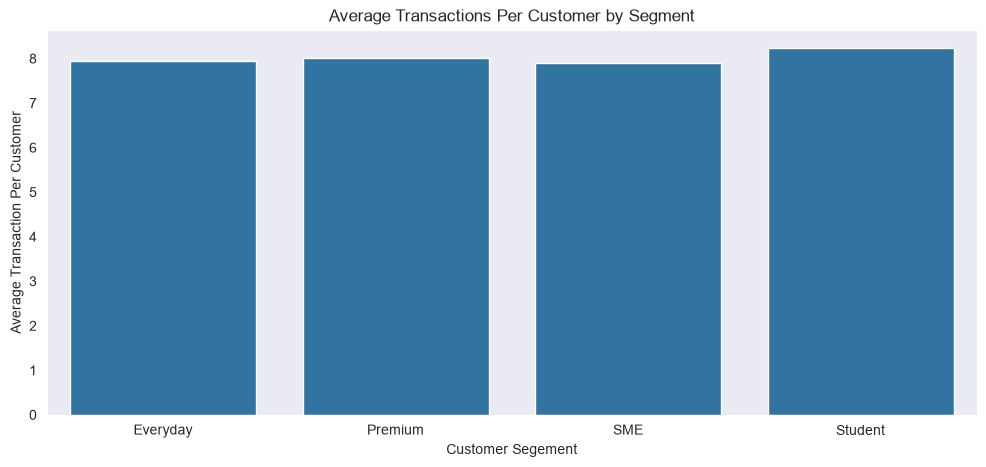

In [49]:
plt.figure(figsize=(12,5))
sns.barplot(
    x=segment_activity['Customer_Segment'],
    y=segment_activity['Average_Transactions_Per_Customer']
)

plt.title("Average Transactions Per Customer by Segment")
plt.ylabel("Average Transaction Per Customer")
plt.xlabel("Customer Segement")
plt.show()

**What does it show?**
The analysis compares the average number of transactions and average total transaction value per customer across the four customer segments. Students have the highest average transaction frequency at 8.23 transactions per customer, while SMEs have the highest average transaction value per customer at approximately NGN 387,923. Everyday customers have the lowest average transaction value at approximately NGN 367,734.

**Why is it important?**
Looking at averages per customer gives a fairer comparison between segments because the segments have different numbers of customers. It helps distinguish the size of a segment from the activity of individual customers.

**Business insight:**
Transaction frequency is fairly similar across all four segments, ranging from about 7.90 to 8.23 transactions per customer. However, the average transaction value differs more, with SME and Student customers showing higher average total transaction values per customer. This suggests that differences in segment transaction value are not mainly driven by how often customers transact, but may be related to the value of individual transactions.